#### 0) Import Libraries

In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_market_calendars as mcal # considers market holidays and unexpected closures that pd date ranges ingnores
import pyarrow as pa # required to use parquet storage file
import pyarrow.parquet as pq 
import json
from pathlib import Path
import matplotlib.pyplot as plt

#### 1) Setup

In [15]:
# Constants
tickers = ["AAPL","META","MSFT","TSLA"]
start_d = "2010-01-01"
end_d = "2025-12-31"

# the code below creates a output directory
output_dir = Path("Data/Processed")
output_dir.mkdir(parents=True, exist_ok=True)

#### 2) Market Calendar Setup

In [16]:
# Valid Trading Mask
nyse = mcal.get_calendar('NYSE')
valid_days = nyse.schedule(start_date=start_d, end_date=end_d)

# Extract just the dates to use as master index
trading_dates = mcal.date_range(valid_days, frequency='1D')


#### 3) Data Load & Cleaning

In [18]:
# Intitialize storage for each ticker's dataframe
raw_data = {}

for ticker in tickers:
    # Load OHLCV data
    df = yf.download(ticker, start=start_d, end=end_d, auto_adjust=True)

    # Flatten the multi-index columns if yf returns them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Standardize column names
    df = df[['Open','High','Low','Close','Volume']]
    df.index = df.index.normalize()

    # Strip the timezone from the yf index
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
        
    # Force alignment to the NYSE calendar
    master_df = pd.DataFrame(index=trading_dates)
    if master_df.index.tz is not None:
        master_df.index = master_df.index.tz_localize(None)

    # Specific Exclusion: META pre-IPO 18th May 2012
    if ticker == 'META':
        df.loc[:"2012-05-17"] = np.nan

    raw_data[ticker] = df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


#### 4) Quality Checks

In [19]:
# Create machine readable audit trail of metadata (data about df)
metadata = {
    "date_range" : {"start" : start_d, "end" : end_d},
    "exclusions" : ["META pre-IPO (before 18th of May 2012)"],
    "adjustments" : "yfinance auto_adjust=True (Splits & Dividends)",
    "quality_checks" : {}
}

# for loop to check for null observations & dupilcated dates
for ticker, df in raw_data.items():
    # Null check (excluding META pre IPO)
    if ticker == "META":
        null_count = df.loc["2012-05-18":].isnull().sum().sum()
    else:
        null_count = df.isnull().sum().sum()
        
    # Duplicated dates Check
    duplicate_dates = df.index.duplicated().sum()

    metadata["quality_checks"][ticker] = {
        "unexpected_nulls" : int(null_count),
        "duplicate_indexes" : int(duplicate_dates)
    }

    print(f"--- {ticker} ---")
    print(f"Nulls: {null_count} | Duplicates: {duplicate_dates}")
    

--- AAPL ---
Nulls: 0 | Duplicates: 0
--- META ---
Nulls: 0 | Duplicates: 0
--- MSFT ---
Nulls: 0 | Duplicates: 0
--- TSLA ---
Nulls: 0 | Duplicates: 0


#### 5) Apply Mask to Null Dates

In [20]:
# We use the masking method to ensure while backtesting the trading engine does not place any order on these days

# Robust Tiered Masking
for ticker, df in raw_data.items():
    # Identify count of non-null columns per row
    data_points_present = df[['Open', 'High', 'Low', 'Close', 'Volume']].notnull().sum(axis=1)
    
    # Logic: If <= 2 columns present, it's a 'Fatal Error' (Mask it)
    # If 3 or more present, we treat it as 'Preserve'
    df['is_valid_day'] = data_points_present > 2
    
    # Optional: Fill missing values for Level 1 (Partial Integrity)
    # If we have 3 or 4 points, we can safely forward-fill the gaps
    # This preserves the row instead of masking it.
    df[['Open', 'High', 'Low', 'Close', 'Volume']] = df[['Open', 'High', 'Low', 'Close', 'Volume']].ffill()
    
    # Update Metadata
    masked_count = (~df['is_valid_day']).sum()
    metadata["quality_checks"][ticker]["masked_days"] = int(masked_count)
    metadata["quality_checks"][ticker]["preserved_partial_days"] = int((data_points_present <= 2).sum())
    
    print(f"--- {ticker} ---")
    print(f"Masked: {masked_count} | Partial Data Preserved: {int((data_points_present > 2).sum())}")

--- AAPL ---
Masked: 0 | Partial Data Preserved: 4023
--- META ---
Masked: 0 | Partial Data Preserved: 3424
--- MSFT ---
Masked: 0 | Partial Data Preserved: 4023
--- TSLA ---
Masked: 0 | Partial Data Preserved: 3901


#### 6) Serialize, Export & Visualize


--- AUDIT FOR AAPL ---
Head of DataFrame:
Price           Open      High       Low     Close     Volume  is_valid_day
Date                                                                       
2010-01-04  6.389117  6.421148  6.357685  6.406480  493729600          True
2010-01-05  6.424144  6.453780  6.383730  6.417558  601904800          True
2010-01-06  6.417559  6.443004  6.308893  6.315479  552160000          True
2010-01-07  6.338826  6.346310  6.258000  6.303801  477131200          True
2010-01-08  6.295420  6.346311  6.258301  6.345712  447610800          True

Summary Statistics:
Price         Open         High          Low        Close        Volume
count  4023.000000  4023.000000  4023.000000  4023.000000  4.023000e+03
mean     77.254046    78.083506    76.480964    77.318819  2.190483e+08
std      74.756845    75.562341    74.033020    74.838151  2.154916e+08
min       5.758679     5.867343     5.695214     5.749099  1.791060e+07
25%      18.202986    18.383943    18.042530

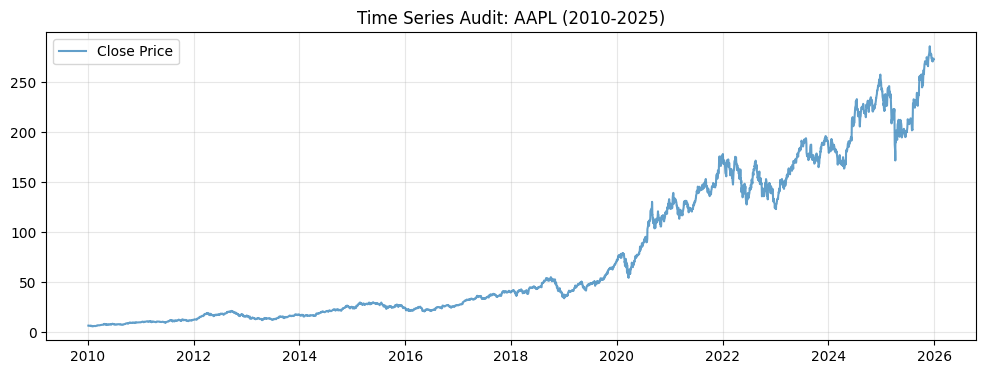


--- AUDIT FOR META ---
Head of DataFrame:
Price            Open       High        Low      Close     Volume  \
Date                                                                
2012-05-18  41.683948  44.608268  37.669204  37.897202  573576400   
2012-05-21  36.211998  36.340867  32.712728  33.733761  168192700   
2012-05-22  32.326128  33.297597  30.670665  30.730143  101786600   
2012-05-23  31.096919  32.217081  31.087006  31.721434   73600000   
2012-05-24  32.663168  32.920903  31.493440  32.742470   50237200   

Price       is_valid_day  
Date                      
2012-05-18          True  
2012-05-21          True  
2012-05-22          True  
2012-05-23          True  
2012-05-24          True  

Summary Statistics:
Price         Open         High          Low        Close        Volume
count  3424.000000  3424.000000  3424.000000  3424.000000  3.424000e+03
mean    219.170208   221.944894   216.360013   219.195694  2.833738e+07
std     177.856207   179.910617   175.545654   

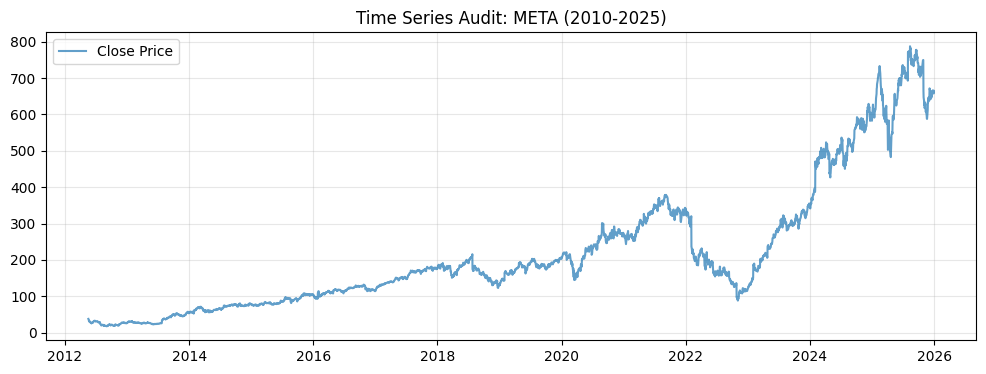


--- AUDIT FOR MSFT ---
Head of DataFrame:
Price            Open       High        Low      Close    Volume  is_valid_day
Date                                                                          
2010-01-04  22.781982  23.139113  22.759661  23.027510  38409100          True
2010-01-05  22.953107  23.139113  22.796861  23.034948  49749600          True
2010-01-06  22.975421  23.124226  22.707574  22.893579  58182400          True
2010-01-07  22.789418  22.841500  22.462049  22.655495  50559700          True
2010-01-08  22.529015  22.975427  22.499253  22.811743  51197400          True

Summary Statistics:
Price         Open         High          Low        Close        Volume
count  4023.000000  4023.000000  4023.000000  4023.000000  4.023000e+03
mean    148.854053   150.229271   147.412806   148.888188  3.530044e+07
std     144.728610   145.959736   143.391931   144.728926  2.058267e+07
min      17.337711    17.510412    17.067396    17.277626  5.855900e+06
25%      30.727476    3

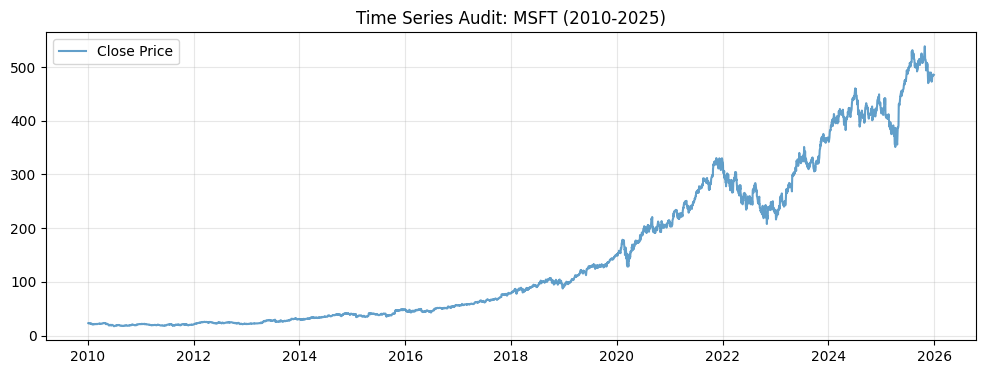


--- AUDIT FOR TSLA ---
Head of DataFrame:
Price           Open      High       Low     Close     Volume  is_valid_day
Date                                                                       
2010-06-29  1.266667  1.666667  1.169333  1.592667  281494500          True
2010-06-30  1.719333  2.028000  1.553333  1.588667  257806500          True
2010-07-01  1.666667  1.728000  1.351333  1.464000  123282000          True
2010-07-02  1.533333  1.540000  1.247333  1.280000   77097000          True
2010-07-06  1.333333  1.333333  1.055333  1.074000  103003500          True

Summary Statistics:
Price         Open         High          Low        Close        Volume
count  3901.000000  3901.000000  3901.000000  3901.000000  3.901000e+03
mean     99.100948   101.275854    96.784247    99.082379  9.675509e+07
std     125.274477   128.004576   122.298044   125.201861  7.571113e+07
min       1.076000     1.108667     0.998667     1.053333  1.777500e+06
25%      12.733333    12.966000    12.538667

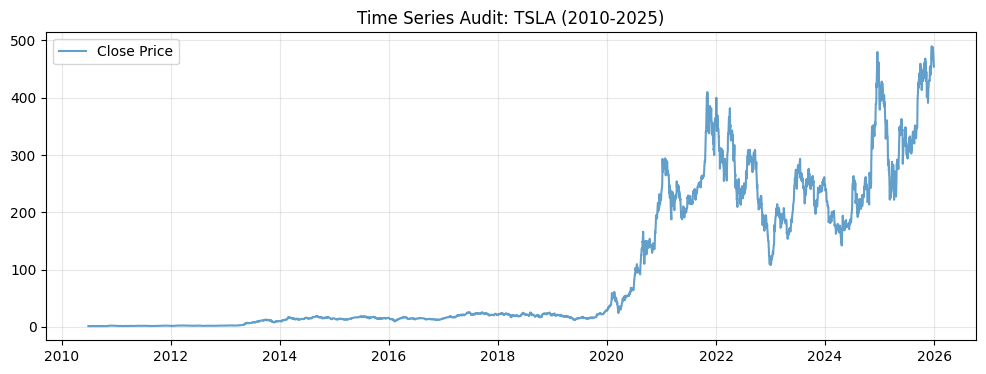

In [22]:
# Final Audit & Visualization
for ticker, df in raw_data.items():
    print(f"\n--- AUDIT FOR {ticker} ---")
    
    # 1. Head of the data
    print("Head of DataFrame:")
    print(df.head())
    
    # 2. Summary Statistics
    print("\nSummary Statistics:")
    print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())
    
    # 3. Visualization
    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df['Close'], label='Close Price', alpha=0.7)
    
    # Highlight missing data points if any exist
    missing = df[~df['is_valid_day']]
    if not missing.empty:
        plt.scatter(missing.index, missing['Close'], color='red', label='Masked Days', s=10)
        
    plt.title(f"Time Series Audit: {ticker} (2010-2025)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [23]:
# Export to Parquet and Metadata
for ticker, df in raw_data.items():
    # We save the full frame, including the 'is_valid_day' column
    table = pa.Table.from_pandas(df)
    pq.write_table(table, output_dir / f"ohlcv_{ticker}.parquet")

# Save the audit trail
with open(output_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)
    
print("Notebook 1 Complete. Data securely persisted with validity masks.")

Notebook 1 Complete. Data securely persisted with validity masks.
